In [7]:
from astropy.io import fits
import matplotlib.pyplot as plt
from astropy.nddata import Cutout2D
from scipy import ndimage
from photutils import aperture
import numpy as np
from tqdm import tqdm

from matplotlib_scalebar.scalebar import ScaleBar
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar

import matplotlib.font_manager as fm

In [37]:
def SpiralContrastFinder(data,spiral,inc):
    meancontrastspiral = []
    r = []
    R = []
    cx = len(data[0])/2
    cy = len(data)/2
    print('Centre: (',cx,',',cy,')')
    for i in range(len(spiral[0])):
        ap = aperture.CircularAperture((spiral[0][i]+cx,spiral[1][i]+cy),2)
        apstats = aperture.ApertureStats(data,ap)
        spiralbrightness = apstats.mean
        r.append(spiral[2][i])

        azimuth = aperture.EllipticalAnnulus((cx,cy),a_in=r[i],a_out=r[i]+4,
                                             b_out=r[i]*np.sin((90-inc)*np.pi/180 )+4,
                                            b_in=r[i]*np.sin((90-inc)*np.pi/180 )
                                            )
        azstats = aperture.ApertureStats(data,azimuth)
        avgbrightness = azstats.mean
        #print('Spiral: ',spiralbrightness,'Avg: ',avgbrightness)
        meancontrastspiral.append(spiralbrightness/avgbrightness)
        u = 16.17*((r[i]*0.012251*370)/100)**1.219 * np.sin(inc*np.pi/180)
        x = spiral[0][i]*0.012251*370
        y = (spiral[1][i]*0.012251*370)+u
        R.append(np.sqrt(x**2 + y**2)) 
        
        

    return meancontrastspiral, R
    

In [38]:
ATPyx = fits.open('fits/AT_Pyx_2024-01-17_Q_phi.fits')[0].data
ATPyx = ndimage.rotate(np.array(Cutout2D(ATPyx,
                                (len(ATPyx[0])/2,len(ATPyx)/2),
                                (100,100)).data),22.11)

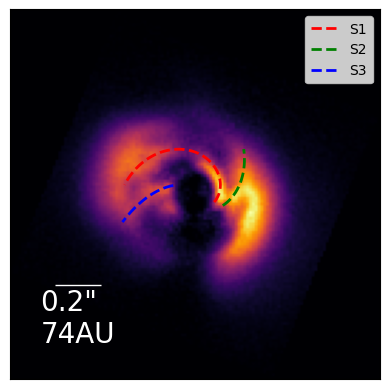

In [44]:
fontprops = fm.FontProperties(size=20)

res = 1

fig,ax=plt.subplots(1,1
                   )
im = ax.imshow(ATPyx,origin='lower',cmap='inferno',vmin=0,#vmax=100,
         extent=[-res*len(ATPyx[0])/2,
                    res*len(ATPyx[0])/2,
                    -res*len(ATPyx[0])/2,
                    res*len(ATPyx[0])/2])

ax.tick_params(
        axis='both',          # changes apply to both axes
        which='both',      # both major and minor ticks are affected
        bottom=False,      # ticks along the bottom edge are off
        top=False, 
        left=False,
        right=False,
        labelbottom=False,
        labelleft=False)


scalebar = AnchoredSizeBar(ax.transData,
                           0.2/0.012251, '0.2"\n74AU', 'lower left', 
                           pad=1,
                           color='white',
                           frameon=False,
                           size_vertical=0.02,
                           fontproperties=fontprops
                           )
ax.add_artist(scalebar)

theta = np.radians(np.linspace(0,360*0.54,1000))
r = (0.09/0.012251)*np.exp(theta * 0.36)
x_2 = r*np.cos(theta-np.radians(22.11))#-(0.0005*theta**3)-0.02
y_2 = r*np.sin(theta-np.radians(22.11))-(0.00018*theta**4)

for i in range(len(theta)):
    r[i] = np.sqrt(x_2[i]**2 + y_2[i]**2)
    theta[i] = np.arctan2(y_2[i],x_2[i])*180/np.pi

spiral1 = [x_2,y_2,r,theta]
plt.plot(x_2,y_2,linestyle='dashed',color='red',linewidth=2)

theta = np.radians(np.linspace(0,360*0.18,1000))
r = (0.13/0.012251)*np.exp(theta * 0.7)
x_2 = r*np.cos(theta-np.radians(22.11))
y_2 = r*np.sin(theta-np.radians(22.11))
for i in range(len(theta)):
    theta[i] = np.arctan2(y_2[i],x_2[i])*180/np.pi
    
    r[i] = np.sqrt(x_2[i]**2 + y_2[i]**2)

spiral2 = [x_2,y_2,r,theta]

plt.plot(x_2,y_2,linestyle='dashed',color='green',linewidth=2)

theta = np.radians(np.linspace(0,360*0.12,1000))
r = -(0.1/0.012251)*np.exp(theta * 1.6)
x_2 = r*np.cos(theta-np.radians(22.11)
              )
y_2 = r*np.sin(theta-np.radians(22.11)
              )
for i in range(len(theta)):
    theta[i] = np.arctan2(y_2[i],x_2[i])*180/np.pi
    
    r[i] = np.sqrt(x_2[i]**2 + y_2[i]**2)

spiral3 = [x_2,y_2,r,theta]

plt.plot(x_2,y_2,linestyle='dashed',color='blue',linewidth=2)

theta = np.radians(np.linspace(-35,45,1000))
r = 0.34
x_2 = r*np.cos(theta)-0.06
y_2 = r*np.sin(theta)-0.04
#plt.plot(x_2,y_2,color='gray',linestyle='dashed',linewidth=4)

theta = np.radians(np.linspace(-45,45,1000)+180)
r = 0.28
x_2 = r*np.cos(theta)-0.06#-(0.03*(theta-np.radians(180))**3)
y_2 = r*np.sin(theta)-0.02
#plt.plot(x_2,y_2,color='gray',linestyle='dashed',linewidth=4)

#ap = aperture.CircularAperture((spiral1[0][300],spiral1[1][300]),2)

#ap_patches = ap.plot(color='white', lw=2,
                           #label='Photometry aperture')

azimuth = aperture.EllipticalAnnulus((0,0),a_in=spiral1[2][300],a_out=spiral1[2][300]+4,
                                             b_out=spiral1[2][300]*np.sin((90-42.5)*np.pi/180)+4,
                                            b_in=spiral1[2][300]*np.sin((90-42.5)*np.pi/180))
#ap_patches = azimuth.plot(color='white', lw=2,
                           #label='Photometry aperture')

plt.legend(['S1','S2','S3','Arcs'])



#plt.savefig('BigATPyx.pdf',bbox_inches='tight')

In [40]:
cont1 = SpiralContrastFinder(ATPyx,spiral1,42.5)
cont2 = SpiralContrastFinder(ATPyx,spiral2,42.5)
cont3 = SpiralContrastFinder(ATPyx,spiral3,42.5)



#print(cont[0][600],cont[1][600])

Centre: ( 65.0 , 65.0 )
Centre: ( 65.0 , 65.0 )
Centre: ( 65.0 , 65.0 )


<>:8: SyntaxWarning: invalid escape sequence '\d'
<>:8: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_4441/1039299906.py:8: SyntaxWarning: invalid escape sequence '\d'
  ax[0].set_ylabel('$\delta$(r)',fontsize=14)


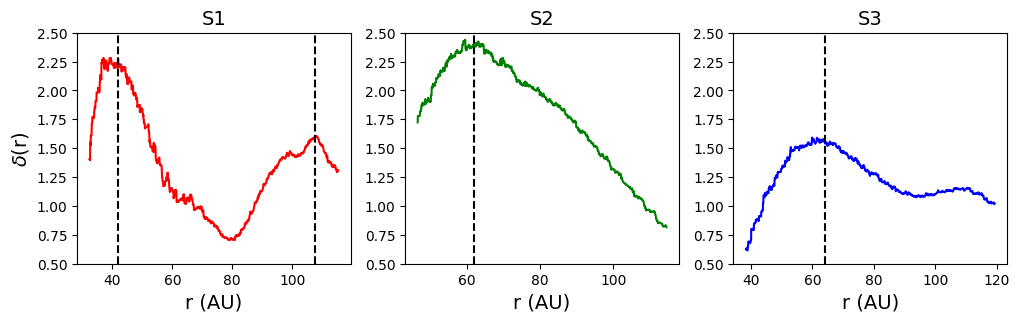

In [49]:
fig,ax = plt.subplots(1,3,figsize=(12,3)
                     )


ax[0].plot(cont1[1],cont1[0],color='red')
ax[0].set_ylim(0.5,2.5)
#ax[0].set_xlim(20,120)
ax[0].set_ylabel('$\delta$(r)',fontsize=14)
ax[0].set_title('S1',fontsize=14)
ax[0].set_xlabel('r (AU)',fontsize=14)
ax[0].plot(42*np.ones(50),np.linspace(0.5,2.5),linestyle='dashed',color='black')
ax[0].plot(107.5*np.ones(50),np.linspace(0.5,2.5),linestyle='dashed',color='black')


ax[1].plot(cont2[1],cont2[0],color='green')
ax[1].set_ylim(0.5,2.5)
ax[1].set_xlabel('r (AU)',fontsize=14)
ax[1].set_title('S2',fontsize=14)
#ax[1].set_xlim(20,120)
ax[1].plot(62*np.ones(50),np.linspace(0.5,2.5),linestyle='dashed',color='black')



ax[2].plot(cont3[1],cont3[0],color='blue')
ax[2].set_ylim(0.5,2.5)
ax[2].set_xlabel('r (AU)',fontsize=14)
ax[2].set_title('S3',fontsize=14)
ax[2].plot(64*np.ones(50),np.linspace(0.5,2.5),linestyle='dashed',color='black')
#ax[2].set_xlim(20,120)
plt.savefig('Spiralcontrast.pdf',bbox_inches='tight')